# Task 3: CLIP

## Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
import umap.umap_ as umap
import clip

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1. Zero-Shot Classification on STL-10

### a) Loading and Initializing CLIP Model (ViT-B/32)

In [5]:
clip_model, transform = clip.load('ViT-B/32', device=device)

100%|███████████████████████████████████████| 338M/338M [05:50<00:00, 1.01MiB/s]


### b) Loading STL-10 Dataset

In [8]:
stl10_testset = datasets.STL10(root='./data', split='test', download=True, transform=transform)
CLASS_NAMES = stl10_testset.classes
stl10_testloader = DataLoader(stl10_testset, batch_size=32, shuffle=False)

Files already downloaded and verified


### Visualizing Samples

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_3900\3114840907.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


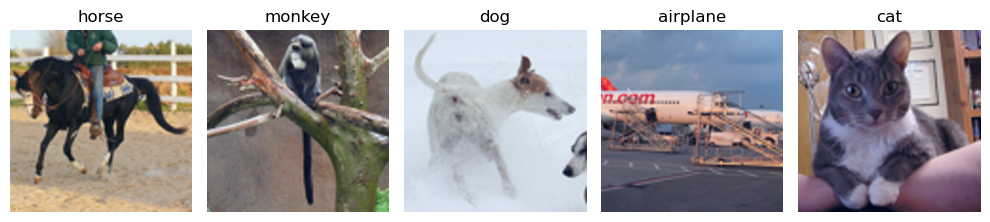

In [10]:
samples, labels = next(iter(stl10_testloader))
fig, axes = plt.subplots(1, 5, figsize=(10,10))
for i, sample in enumerate(samples[:5]):
    sample = sample.permute(1, 2, 0).detach().numpy()
    sample = (sample - sample.min()) / (sample.max() - sample.min())
    label = labels[i]
    axes[i].imshow(sample)
    axes[i].axis('off')
    axes[i].set_title(CLASS_NAMES[label])

fig.tight_layout()
fig.show()

### d) Evaluating Dataset on Different prompting techniques

In [ ]:
def evaluate(class_names):
    fig, axes = plt.subplots(5,1, figsize=(10, 10))

    clip_model.eval()
    with torch.no_grad():
        text = class_names
        tokens = clip.tokenize(text).to(device)
        text_z = clip_model.encode_text(tokens)
        text_z = text_z / text_z.norm(dim=-1, keepdim=True)

        correct = 0
        total = 0
        for i, (samples, labels) in enumerate(tqdm(stl10_testloader, desc='Evaluating')):
            batch_size = samples.size(0)
            samples, labels = samples.to(device), labels.to(device)
            img_z:torch.Tensor = clip_model.encode_image(samples)
            img_z = img_z / img_z.norm(dim=-1, keepdim=True)

            similarity = img_z @ text_z.T
            preds = torch.argmax(similarity, dim=-1)

            correct += (preds == labels).sum().item()
            total += batch_size

            if i < 5:
                sample:torch.Tensor = samples[0]
                sample = sample.permute(1, 2, 0).detach().cpu().numpy()
                sample = (sample - sample.min()) / (sample.max() - sample.min())
                label = labels[0]
                pred = preds[0].detach().cpu().item()

                axes[i].imshow(sample)
                axes[i].axis('off')
                axes[i].set_title(f"Predicted: {text[pred]}\nTrue: {text[label]}")

        print("Variant 1: ")
        plt.tight_layout()
        plt.show()
        acc = correct / total
        return acc

Evaluating on Plain Labels (cat, dog, etc)


Evaluating: 100%|██████████| 250/250 [00:21<00:00, 11.66it/s]


Variant 1: 


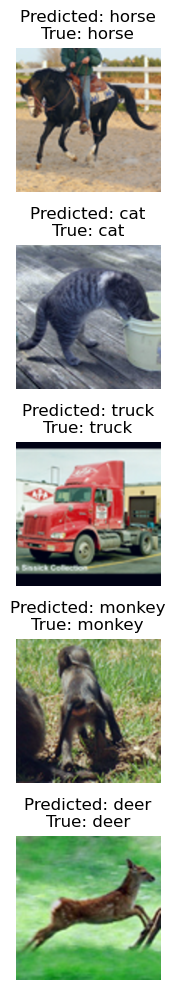

Evaluating on descriptive labels (Variant 2)


Evaluating: 100%|██████████| 250/250 [00:21<00:00, 11.54it/s]

Variant 1: 


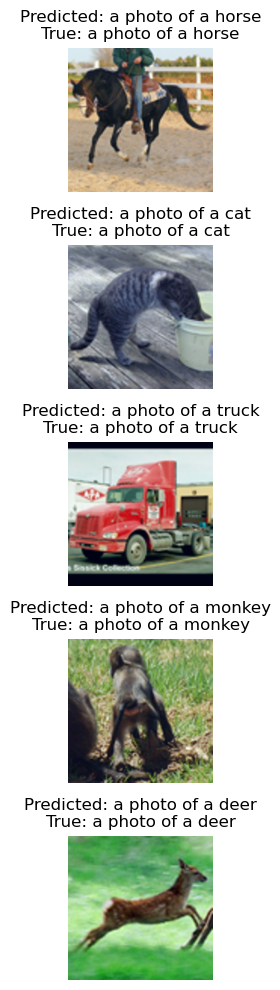

Evaluating on more complex and descriptive labels (Variant 3)


Evaluating: 100%|██████████| 250/250 [00:21<00:00, 11.47it/s]


Variant 1: 


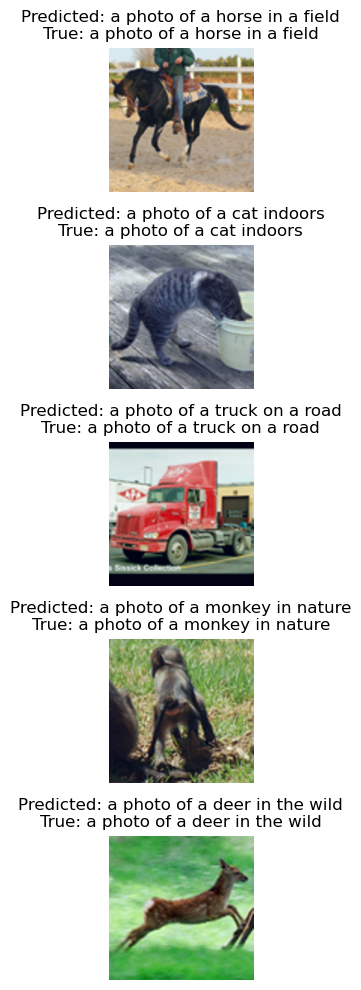

In [24]:
VAR1 = CLASS_NAMES

VAR2 = ["a photo of an airplane", "a photo of a bird", "a photo of a car", "a photo of a cat", "a photo of a deer", "a photo of a dog", "a photo of a horse", "a photo of a monkey", "a photo of a ship", "a photo of a truck"]

VAR3 = ["a photo of an airplane in the sky", "a photo of a bird in nature", "a photo of a car on a road", "a photo of a cat indoors", "a photo of a deer in the wild", "a photo of a dog outdoors", "a photo of a horse in a field", "a photo of a monkey in nature", "a photo of a ship on water", "a photo of a truck on a road"]

print("Evaluating on Plain Labels (cat, dog, etc)")
variant1_acc = evaluate(VAR1)
print("Evaluating on descriptive labels (Variant 2)")
variant2_acc = evaluate(VAR2)
print("Evaluating on more complex and descriptive labels (Variant 3)")
variant3_acc = evaluate(VAR3)

In [25]:
print(f"Validation Accuracy for Variant 1: {(variant1_acc * 100):.2f}%")  
print(f"Validation Accuracy for Variant 2: {(variant2_acc * 100):.2f}%")  
print(f"Validation Accuracy for Variant 3: {(variant3_acc * 100):.2f}%")  

Validation Accuracy for Variant 1: 96.28%
Validation Accuracy for Variant 2: 97.36%
Validation Accuracy for Variant 3: 93.04%


### Analysis

All the three variants despite every successive variant being complex and more descriptive, gave almost comparable validation accuracy on whole STL-10 Test Dataset, showing that CLIP gives zero-shot classification and generality of any variant of caption present.

## 2. Exploring the Modality Gap

In [49]:
stl10_testloader = DataLoader(stl10_testset, batch_size=200, shuffle=False)

### a) Extracting embeddings

In [56]:
samples, labels = next(iter(stl10_testloader))
tokens = clip.tokenize(CLASS_NAMES).to(device)
text_z = clip_model.encode_text(tokens)
text_z /= text_z.norm(dim=-1, keepdim=True)

clip_model.eval()
embeddings = []
text_embs = []
img_embs = []
with torch.no_grad():
    for i, sample in enumerate(tqdm(samples, desc="Extracting embeddings")):
        label = labels[i].item()
        sample = sample.to(device)
        text_emb:torch.Tensor = text_z[label]
        img_emb:torch.Tensor = clip_model.encode_image(sample.unsqueeze(0)).squeeze()
        img_emb /= img_emb.norm(dim=-1, keepdim=True)
        text_embs.append(text_emb.detach().cpu().numpy())
        img_embs.append(img_emb.detach().cpu().numpy())

embeddings = np.concat([img_embs, text_embs], axis=0)

Extracting embeddings: 100%|██████████| 200/200 [00:02<00:00, 90.21it/s] 


### b) & c) Dimensionality reduction using UMAP

c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


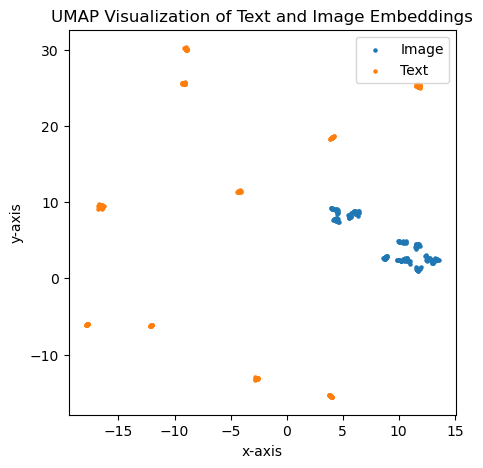

In [57]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_map = reducer.fit_transform(embeddings)
img_points = embedding_map[:len(img_embs)]
text_points = embedding_map[len(img_embs):]

plt.figure(figsize=(5,5))
plt.scatter(img_points[:, 0], img_points[:, 1], label="Image", s=5)
plt.scatter(text_points[:, 0], text_points[:, 1], label="Text", s=5)
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('UMAP Visualization of Text and Image Embeddings')
plt.legend()
plt.show()

### d) Analysis

**How separated are the two modalities?**

The UMAP plot shows a clear separation between text and image embeddings. Image embeddings form a tight cluster, while text embeddings are spread out and lie mostly outside this cluster. This visible gap between the two modality clusters is known as the **modality gap**.

**Does normalization affect the modality gap?**

No. All the embeddings are normalized, but normalization only projects embeddings onto a unit hypersphere so it does not force text and image embeddings into the same region of that space. The gap comes from differences in encoder architecture, training dynamics, and each modality's initial embedding distribution, so it persists even after normalization.

**Why does CLIP still perform well despite this gap?**

CLIP is trained with a **contrastive objective** that only requires matching image-text pairs to have *relatively* higher cosine similarity than non-matching pairs and it does not require both modalities to occupy the same embedding region. Since the relative ordering of similarities within each modality is preserved, retrieval and zero-shot classification still work correctly even though the absolute embedding spaces remain separated.

## 3. Bridging the Modality Gap

In [63]:
from scipy.linalg import orthogonal_procrustes as procrustes

samples, labels = next(iter(stl10_testloader))
tokens = clip.tokenize(CLASS_NAMES).to(device)
text_z = clip_model.encode_text(tokens)
text_z /= text_z.norm(dim=-1, keepdim=True)

clip_model.eval()
embeddings = []
text_embs = []
img_embs = []
with torch.no_grad():
    for i, sample in enumerate(tqdm(samples, desc="Extracting embeddings")):
        label = labels[i].item()
        sample = sample.to(device)
        text_emb:torch.Tensor = text_z[label]
        img_emb:torch.Tensor = clip_model.encode_image(sample.unsqueeze(0))
        img_emb /= img_emb.norm(dim=-1, keepdim=True)
        text_embs.append(text_emb.unsqueeze(0).detach().cpu().numpy())
        img_embs.append(img_emb.detach().cpu().numpy())

text_embs = np.concat(text_embs, axis=0)
img_embs = np.concat(img_embs, axis=0)
R, scale = procrustes(img_embs, text_embs)

img_embs_aligned = img_embs @ R

embeddings = np.concat([img_embs_aligned, text_embs], axis=0)

Extracting embeddings: 100%|██████████| 200/200 [00:01<00:00, 108.42it/s]


c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


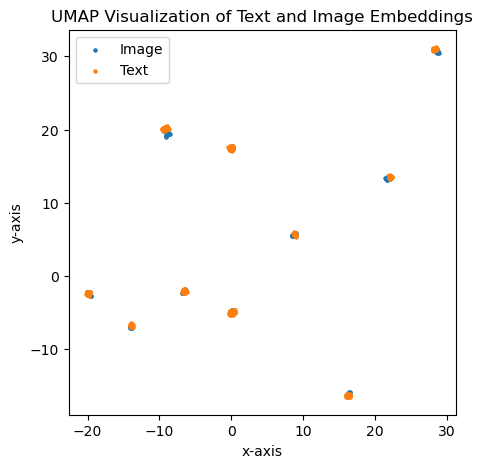

In [64]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_map = reducer.fit_transform(embeddings)
img_points = embedding_map[:len(img_embs)]
text_points = embedding_map[len(img_embs):]

plt.figure(figsize=(5,5))
plt.scatter(img_points[:, 0], img_points[:, 1], label="Image", s=5)
plt.scatter(text_points[:, 0], text_points[:, 1], label="Text", s=5)
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('UMAP Visualization of Text and Image Embeddings')
plt.legend()
plt.show()

### Analysis

**How does the alignment affect the modality gap?**

The orthogonal Procrustes alignment removes the modality gap almost completely. After applying the learned rotation **R**, the text and image embeddings that were previously separated into two distinct clusters now overlap closely, with each image embedding lying near its corresponding text embedding. This shows that the modality gap was mainly a **linear rotational/positional offset** between the two embedding spaces, not a deep semantic difference. Since Procrustes alignment preserves relative distances and angles while only rotating and shifting the space, its success in closing the gap confirms that CLIP's text and image encoders already learn similar relative structures and they were just oriented differently in the embedding space.

### Evaluating Model on Aligned Image Embeddings

In [67]:
stl10_testloader = DataLoader(stl10_testset, batch_size=32, shuffle=False)

In [96]:
tokens = clip.tokenize(CLASS_NAMES).to(device)
text_z = clip_model.encode_text(tokens)
text_z /= text_z.norm(dim=-1, keepdim=True)

clip_model.eval()
text_embs = []
img_embs = []
labels_list = []
with torch.no_grad():
    for samples, labels in tqdm(stl10_testloader, desc="Extracting embeddings"):
        samples = samples.to(device)
        img_z = clip_model.encode_image(samples)
        img_z = img_z.unbind(dim=0)
        img_embs.extend([x.detach().cpu().numpy() for x in img_z])

        text_emb = [text_z[label.item()].detach().cpu().numpy() for label in labels]
        text_embs.extend(text_emb)
        labels_list.extend(labels.unbind(dim=0))

text_embs = np.stack(text_embs, axis=0)
img_embs = np.stack(img_embs, axis=0)
labels = torch.stack(labels_list, dim=0).reshape(-1, 1)
print("Learning transformation R...")
R, scale = procrustes(img_embs, text_embs)
print("Applying alignment transformation...")
img_embs_aligned = img_embs @ R
print("Done.")

Extracting embeddings: 100%|██████████| 250/250 [00:21<00:00, 11.48it/s]


Learning transformation R...
Applying alignment transformation...
Done.


In [97]:
print("Text Embeddings Shape:", text_embs.shape)
print("Image Embeddings Shape:", img_embs_aligned.shape)
print("Labels Shape:", labels.shape)

Text Embeddings Shape: (8000, 512)
Image Embeddings Shape: (8000, 512)
Labels Shape: torch.Size([8000, 1])


In [103]:
def evaluate_aligned(class_names, aligned_img_embs, labels):
    clip_model.eval()
    with torch.no_grad():
        text = class_names
        tokens = clip.tokenize(text).to(device)
        text_z = clip_model.encode_text(tokens)
        text_z = text_z / text_z.norm(dim=-1, keepdim=True)
        img_z = torch.from_numpy(aligned_img_embs).to(device).to(torch.float16)
        labels = labels.to(device).reshape(-1)

        total = labels.size(0)

        similarity = img_z @ text_z.T
        preds = torch.argmax(similarity, dim=1)
        correct = (preds == labels).sum().item()

    acc = correct / total
    return acc
        

In [104]:
print("Evaluating on Plain Labels (cat, dog, etc)")
aligned_acc = evaluate_aligned(CLASS_NAMES, img_embs_aligned, labels)
print("Done")

Evaluating on Plain Labels (cat, dog, etc)
Done


In [105]:
print(f"Validation Accuracy on Aligned Image Embeddings: {(aligned_acc * 100):.2f}%")

Validation Accuracy on Aligned Image Embeddings: 97.74%


### Comparison of Accuracy and Analysis

Accuracy on Baseline CLIP ViT: 96.28%

Accuracy on Aligned Image Embeddings Evaluation: 97.74%

### Analysis

The accuracies from both evaluations are nearly identical, showing that although a clear modality gap exists in CLIP's embedding space, closing this gap through alignment does not meaningfully improve classification accuracy. This is because CLIP's classification performance depends mainly on how well each modality (text and image) is encoded independently, not on how close or far the text and image embeddings are positioned relative to each other in the shared feature space.